# Analysis

In [1]:
from typing import Optional

import time
import nglview as nv
import pandas as pd
from pubchempy import Compound, get_compounds, download
from rdkit import Chem
from rdkit.Chem.rdchem import Mol
from rdkit.Chem import (
    AllChem,
    rdCoordGen,
    rdDepictor,
    PandasTools,
    Draw
)
from rdkit.Chem.Draw import IPythonConsole

from src.utils.generate_mirror import invert_mol


In [ ]:
dataset = pd.read_csv(
        "../data/antibiotics_pubchem_query.csv", index_col=0
    )


In [ ]:
dataset.head()


,amoxicillin,piperacillin,ticarcillin,cefepime,cefazolin,ceftolozane,ceftriaxone,ceftazidime,aztreonam,imipenem,...,linezolid,amikacin,tobramycin,streptomycin,kanamycin,trimethoprim,sulfamethoxazole,ciprofloxacin,levofloxacin,Moxifloxacin
cid,33613,43672,36921,5479537,33255,53234134,5479530,5481173,5742832,104838,...,441401,37768,36294,19649,6032,5578,5329,2764,149096,152946
smiles,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,CCN1CCN(C(=O)C1=O)C(=O)N[C@H](C2=CC=CC=C2)C(=O...,CC1([C@@H](N2[C@H](S1)[C@@H](C2=O)NC(=O)[C@@H]...,C[N+]1(CCCC1)CC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC1=NN=C(S1)SCC2=C(N3[C@@H]([C@@H](C3=O)NC(=O)...,CC(C)(C(=O)O)O/N=C(/C1=NSC(=N1)N)\C(=O)N[C@H]2...,CN1C(=NC(=O)C(=O)N1)SCC2=C(N3[C@@H]([C@@H](C3=...,CC(C)(C(=O)O)O/N=C(/C1=CSC(=N1)N)\C(=O)N[C@H]2...,C[C@H]1[C@@H](C(=O)N1S(=O)(=O)O)NC(=O)/C(=N\OC...,C[C@H]([C@@H]1[C@H]2CC(=C(N2C1=O)C(=O)O)SCCN=CN)O,...,CC(=O)NC[C@H]1CN(C(=O)O1)C2=CC(=C(C=C2)N3CCOCC3)F,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1NC(=O)[C@H]...,C1[C@@H]([C@H]([C@@H]([C@H]([C@@H]1N)O[C@@H]2[...,C[C@H]1[C@@]([C@H]([C@@H](O1)O[C@@H]2[C@H]([C@...,C1[C@H]([C@@H]([C@H]([C@@H]([C@H]1N)O[C@@H]2[C...,COC1=CC(=CC(=C1OC)OC)CC2=CN=C(N=C2N)N,CC1=CC(=NO1)NS(=O)(=O)C2=CC=C(C=C2)N,C1CC1N2C=C(C(=O)C3=CC(=C(C=C32)N4CCNCC4)F)C(=O)O,C[C@H]1COC2=C3N1C=C(C(=O)C3=CC(=C2N4CCN(CC4)C)...,COC1=C2C(=CC(=C1N3C[C@@H]4CCCN[C@@H]4C3)F)C(=O...
inchi,InChI=1S/C16H19N3O5S/c1-16(2)11(15(23)24)19-13...,InChI=1S/C23H27N5O7S/c1-4-26-10-11-27(19(32)18...,InChI=1S/C15H16N2O6S2/c1-15(2)9(14(22)23)17-11...,InChI=1S/C19H24N6O5S2/c1-25(5-3-4-6-25)7-10-8-...,InChI=1S/C14H14N8O4S3/c1-6-17-18-14(29-6)28-4-...,"InChI=1S/C23H30N12O8S2/c1-23(2,20(40)41)43-31-...",InChI=1S/C18H18N8O7S3/c1-25-18(22-12(28)13(29)...,"InChI=1S/C22H22N6O7S2/c1-22(2,20(33)34)35-26-1...","InChI=1S/C13H17N5O8S2/c1-5-7(10(20)18(5)28(23,...",InChI=1S/C12H17N3O4S/c1-6(16)9-7-4-8(20-3-2-14...,...,InChI=1S/C16H20FN3O4/c1-11(21)18-9-13-10-20(16...,InChI=1S/C22H43N5O13/c23-2-1-8(29)20(36)27-7-3...,InChI=1S/C18H37N5O9/c19-3-9-8(25)2-7(22)17(29-...,"InChI=1S/C21H39N7O12/c1-5-21(36,4-30)16(40-17-...",InChI=1S/C18H36N4O11/c19-2-6-10(25)12(27)13(28...,InChI=1S/C14H18N4O3/c1-19-10-5-8(6-11(20-2)12(...,InChI=1S/C10H11N3O3S/c1-7-6-10(12-16-7)13-17(1...,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,InChI=1S/C18H20FN3O4/c1-10-9-26-17-14-11(16(23...,InChI=1S/C21H24FN3O4/c1-29-20-17-13(19(26)14(2...
coordinate_type,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d,...,2d,2d,2d,2d,2d,2d,2d,2d,2d,2d
xlogp,-2,0.5,0.8,-0.1,-0.4,-3.2,-1.3,0.4,0.3,-0.7,...,0.7,-7.9,-6.2,-8,-6.9,0.9,0.9,-1.1,-0.4,0.6


In [ ]:
struct: list[Mol] = []

for ab in dataset:
    struct.append(
        Chem.MolFromSmiles(dataset[ab]["smiles"])
    )


In [ ]:
dataset.loc["struct"] = struct # append the structure
dataset.tail()


,amoxicillin,piperacillin,ticarcillin,cefepime,cefazolin,ceftolozane,ceftriaxone,ceftazidime,aztreonam,imipenem,...,linezolid,amikacin,tobramycin,streptomycin,kanamycin,trimethoprim,sulfamethoxazole,ciprofloxacin,levofloxacin,Moxifloxacin
h_bond_donor_count,4,3,3,2,2,7,4,3,4,3,...,1,13,10,12,11,2,2,2,1,2
h_bond_acceptor_count,7,8,8,10,12,16,13,12,12,6,...,6,17,14,15,15,7,6,7,8,8
rotatable_bond_count,4,6,5,6,7,11,8,8,7,6,...,4,10,6,9,6,5,3,3,2,4
cactvs_fingerprint,1110000001111011001110000000000001000000000000...,1110000001111011101110000000000001000000000000...,1110000001110011001110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1100000001110011111110000000000001100000000000...,1110000001111011111111000000000001100000000000...,1110000001111011111110000000000001100000000000...,1110000001111011101110000000000001100000000000...,1110000001110011101111000000000001100000000000...,1110000001110011001110000000000001000000000000...,...,1110000001111011001110010000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1111000001111011101111000000000000000000000000...,1110000001110011101100000000000000000000000000...,1100000001110011001100000000000001000000000000...,1110000001111011001100010000000000000000000000...,1110000001111011001110010000000000000000000000...,1110000001111011001110010000000000000000000000...
struct,<rdkit.Chem.rdchem.Mol object at 0x7f1ada164660>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada164350>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada1643c0>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada164740>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada164430>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada164510>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada1644a0>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada164820>,<rdkit.Chem.rdchem.Mol object at 0x7f1ad9fe1230>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada120660>,...,<rdkit.Chem.rdchem.Mol object at 0x7f1ada120a50>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada123e60>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada123ed0>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada123f40>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada120ac0>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada120ba0>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada120c10>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada120c80>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada121620>,<rdkit.Chem.rdchem.Mol object at 0x7f1ada121690>


Group the antibiotics per mechanism/class, ie beta-lactams, tetracyclines, per row.

In [ ]:
antibiotics_arr = [
        [
            "amoxicillin", # penicillins
            "piperacillin",
            "ticarcillin"
        ], [
            "cefepime", # cephalosporins
            "cefazolin",
            "ceftolozane",
            "ceftriaxone",
            "ceftazidime",
        ], [
            "aztreonam" # monobactam
        ], [
            "imipenem", # carbapenems
            "meropenem",
            "doripenem"
        ], [
            "vancomycin" # glycopeptide
        ], [
            "minocycline", # tetracyclines
            "tigecycline",
            "doxycycline",
            "tetracycline",
            "Chlortetracycline"
        ], [
            "azithromycin", # macrolides
            "erythromycin",
            "clarithromycin"
        ], [
            "chloramphenicol" # chlorampenicol
        ], [
            "linezolid" # oxazolidinones
        ], [
            "amikacin", # aminoglycosides
            "tobramycin",
            "streptomycin",
            "kanamycin"
        ], [
            "trimethoprim" # trimethoprim
        ], [
            "sulfamethoxazole" # sulfamethoxazole
        ], [
            "ciprofloxacin", # quinolones
            "levofloxacin",
            "Moxifloxacin"
        ]
    ]


In [ ]:
legends_arr: list[str] = []
struct_arr: list[Mol] = []

mirror_arr: list[Mol] = []
mirr_legends_arr: list[str] = []

for ab_arr in antibiotics_arr:
    mirror_subarr: list[Mol] = [] # mirror-type molecule
    mirr_legends_subarr: list[str] = []
    struct_subarr: list[Mol] = [] # native molecule conformation
    legends_subarr: list[str] = []

    for ab in ab_arr:
        cid = dataset[ab]["cid"]

        mirror_mol: Mol = Chem.MolFromSmiles(dataset[ab]["smiles"])
        native_mol: Mol = dataset[ab]["struct"]

        for atom in mirror_mol.GetAtoms():
            atom.InvertChirality()
        Chem.MolToMolFile(
            native_mol, f"../data/native_ligands/{cid}.mol"
        )
        Chem.MolToMolFile(
            mirror_mol, f"../data/mirror_ligands/mirror-{cid}.mol"
        )

        mirror_subarr.append(mirror_mol) # mirror-type molecule
        mirr_legends_subarr.append(f"Mirror {ab.title()}")
        struct_subarr.append(native_mol) # native molecule conformation
        legends_subarr.append(ab.title())

    mirror_arr.append(mirror_subarr) # mirror-type molecule
    mirr_legends_arr.append(mirr_legends_subarr)
    struct_arr.append(struct_subarr) # native molecule conformation
    legends_arr.append(legends_subarr)


## Native Ligands

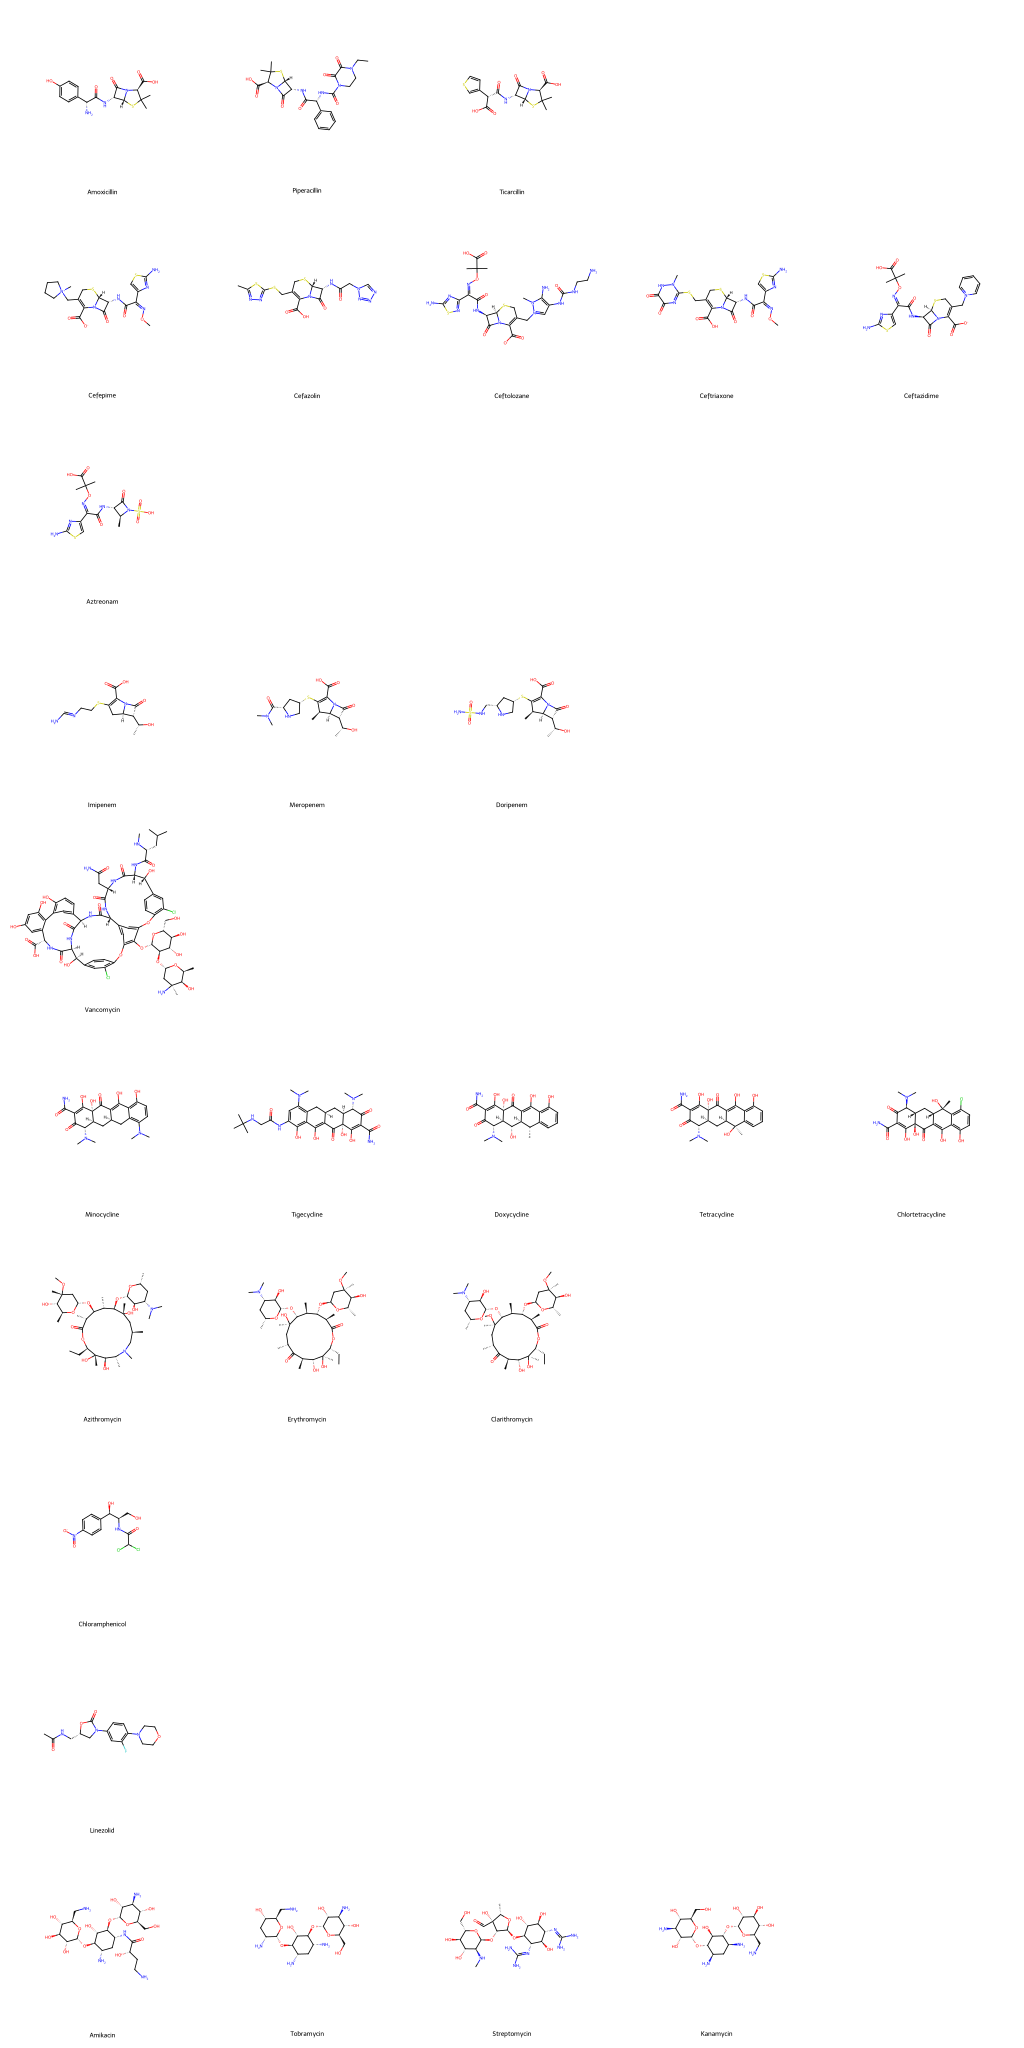

In [ ]:
img = Draw.MolsMatrixToGridImage(
    molsMatrix=struct_arr,
    legendsMatrix=legends_arr,
    subImgSize=(512, 512),
    useSVG=True,

)

# with open(
#         "../output/antibiotics_arr.svg", "w", encoding="utf-8"
#     ) as out:
    # out.write(img.data)
img


## Mirror Ligands

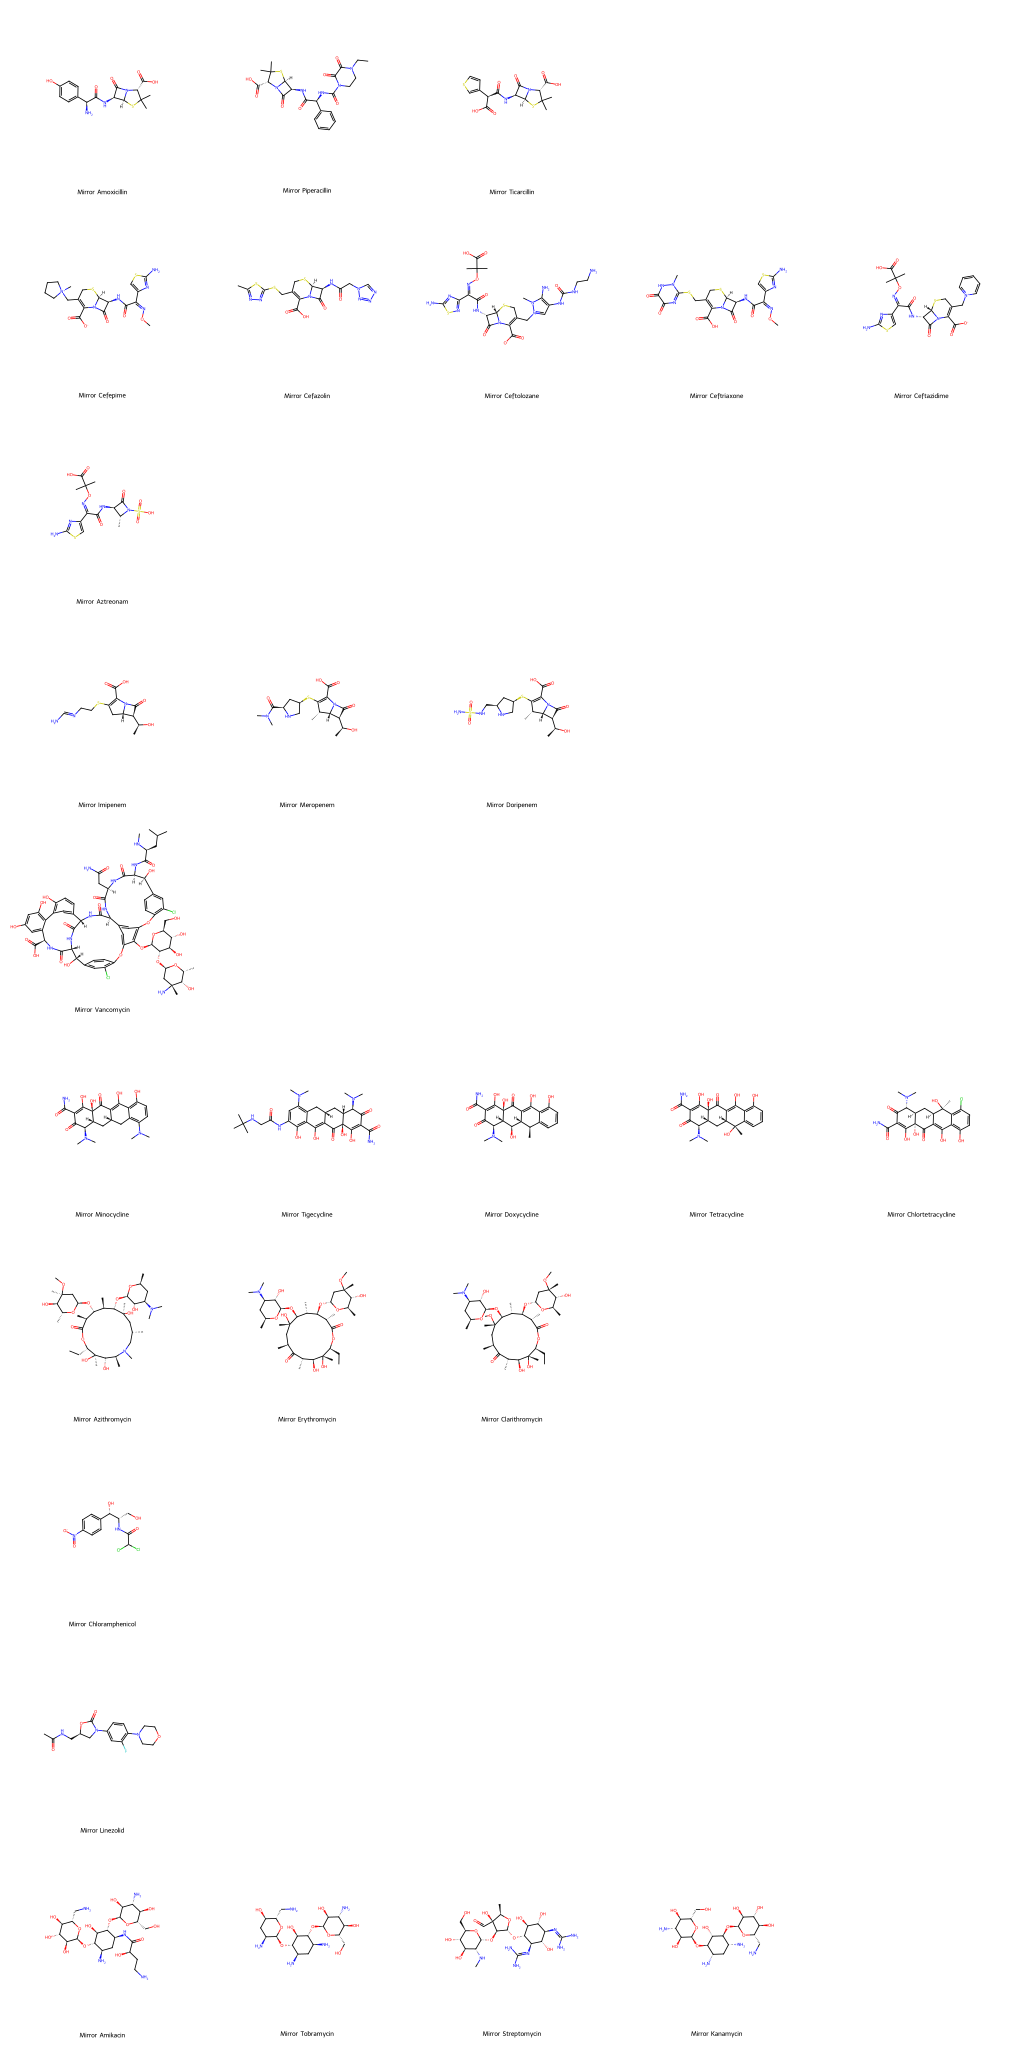

In [ ]:
img = Draw.MolsMatrixToGridImage(
    molsMatrix=mirror_arr,
    legendsMatrix=mirr_legends_arr,
    subImgSize=(512, 512),
    useSVG=True,

)

# with open(
#         "../output/mirror_antibiotics_arr.svg", "w", encoding="utf-8"
#     ) as out:
#     out.write(img.data)
img


## Verification